En esta actividad se trabaja con el archivo `usuarios_win_mac_lin.csv`.

El objetivo es aplicar regresión logística para predecir qué sistema operativo utiliza un usuario que visita un sitio web.

Las etiquetas son:

- `0`: Windows
- `1`: Macintosh
- `2`: Linux


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("usuarios_win_mac_lin.csv")

df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [4]:
df.shape

df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB


,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


El archivo tiene cinco columnas:

- duracion: duración de la visita en segundos.
- paginas: cantidad de páginas vistas durante la sesión.
- acciones: cantidad de acciones realizadas por el usuario.
- valor: suma del valor de las acciones.
- clase: sistema operativo del usuario.

La columna clase es la variable que se quiere predecir.


Las variables de entrada son las cuatro características tomadas de Google Analytics.  
La variable de salida es la clase del sistema operativo.

In [5]:
X = df[["duracion", "paginas", "acciones", "valor"]]
Y = df["clase"]

X.head()
Y.head()

,clase
0,2
1,2
2,2
3,2
4,2


Se realizan gráficos de dispersión para observar si los datos se agrupan según la clase del sistema operativo.


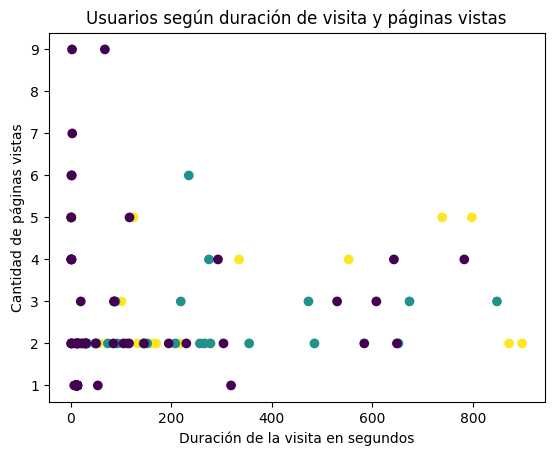

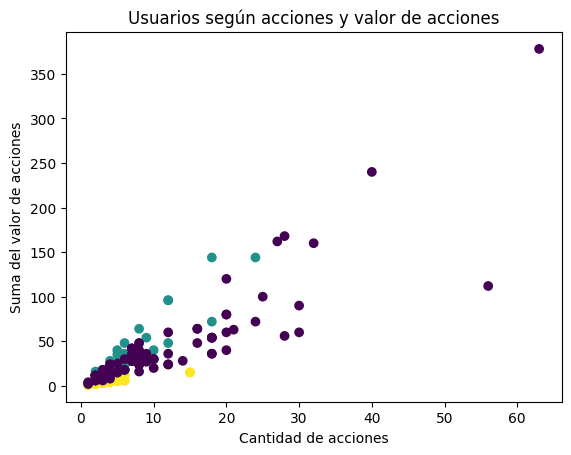

In [6]:
plt.scatter(df["duracion"], df["paginas"], c=Y)
plt.title("Usuarios según duración de visita y páginas vistas")
plt.xlabel("Duración de la visita en segundos")
plt.ylabel("Cantidad de páginas vistas")
plt.show()

plt.scatter(df["acciones"], df["valor"], c=Y)
plt.title("Usuarios según acciones y valor de acciones")
plt.xlabel("Cantidad de acciones")
plt.ylabel("Suma del valor de acciones")
plt.show()

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (136, 4)
Datos de prueba: (34, 4)


Como la salida es discreta, se utiliza un modelo de clasificación mediante regresión logística.


In [8]:
clasificador = LogisticRegression(max_iter=1000)

clasificador.fit(X_train, Y_train)


LogisticRegression(max_iter=1000)

Se utiliza el método `predict()` para predecir el sistema operativo de los usuarios del conjunto de prueba.


In [9]:
predicciones = clasificador.predict(X_test)

predicciones

comparacion = pd.DataFrame({
    "Valor real": Y_test.values,
    "Valor predicho": predicciones
})

comparacion.head(10)

,Valor real,Valor predicho
0,0,0
1,1,1
2,2,2
3,1,1
4,0,0
5,0,0
6,0,0
7,0,0
8,1,0
9,0,2


Se crea un ejemplo nuevo con las cuatro características de entrada:


In [16]:
nuevo_usuario = pd.DataFrame(
    [[180, 5, 12, 25]],
    columns=["duracion", "paginas", "acciones", "valor"]
)

prediccion = clasificador.predict(nuevo_usuario)

prediccion

if prediccion[0] == 0:
    print("El usuario probablemente utiliza Windows")
elif prediccion[0] == 1:
    print("El usuario probablemente utiliza Macintosh")
else:
    print("El usuario probablemente utiliza Linux")

El usuario probablemente utiliza Windows
